# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING

#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

In [3]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43 or i in [7,8,11,13,18,24,29,31,35,36,37,38,40,47,48,50,54,58,59,63,67,70,71]:
        continue  # Skip participant 1,28 due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:processed_epochs\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average', projection=False)

            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=60.0, overlap=0.0,preload=True)

            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            epochs.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            epochs.interpolate_bads(reset_bads=True)
            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)        

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        if (i == 39 or i == 43) and j == 2:
            data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 56:  # Training data
            X_train_list.append(data)
            y_train_list.append(epoch_labels)
        else:  # Testing data
            X_test_list.append(data)
            y_test_list.append(epoch_labels)

# After the loop, concatenate into arrays
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)
print("Training and testing data processing complete")

Loading processed epochs from D:processed_epochs\sub-02_ses-1_epochs.fif
Reading D:\processed_epochs\sub-02_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-02_ses-2_epochs.fif
Reading D:\processed_epochs\sub-02_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-03_ses-1_epochs.fif


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-03_ses-2_epochs.fif
Reading D:\processed_epochs\sub-03_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-04_ses-1_epochs.fif
Reading D:\processed_epochs\sub-04_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-03_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-04_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-04_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-04_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-05_ses-1_epochs.fif
Reading D:\processed_epochs\sub-05_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-05_ses-2_epochs.fif
Reading D:\processed_epochs\sub-05_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-05_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-05_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-06_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-06_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-06_ses-2_epochs.fif
Reading D:\processed_epochs\sub-06_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-09_ses-1_epochs.fif
Reading D:\processed_epochs\sub-09_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-06_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-09_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-09_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-09_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-10_ses-1_epochs.fif
Reading D:\processed_epochs\sub-10_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-10_ses-2_epochs.fif
Reading D:\processed_epochs\sub-10_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-10_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-10_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-12_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-12_ses-2_epochs.fif
Reading D:\processed_epochs\sub-12_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-14_ses-1_epochs.fif
Reading D:\processed_epochs\sub-14_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-12_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-14_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-14_ses-2_epochs.fif
Reading D:\processed_epochs\sub-14_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-15_ses-1_epochs.fif
Reading D:\processed_epochs\sub-15_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-15_ses-2_epochs.fif
Reading D:\processed_epochs\sub-15_ses-2_epochs.fif ...


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-14_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-15_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-15_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-16_ses-1_epochs.fif
Reading D:\processed_epochs\sub-16_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-16_ses-2_epochs.fif
Reading D:\processed_epochs\sub-16_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-17_ses-1_epoch

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-16_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-16_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-17_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-17_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-17_ses-2_epochs.fif
Reading D:\processed_epochs\sub-17_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-19_ses-1_epochs.fif
Reading D:\processed_epochs\sub-19_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-17_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-19_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-19_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-20_ses-1_epochs.fif
Reading D:\processed_epochs\sub-20_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-20_ses-2_epochs.fif
Reading D:\processed_epochs\sub-20_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-20_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-20_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


0 projection items activated
Loading processed epochs from D:processed_epochs\sub-21_ses-1_epochs.fif
Reading D:\processed_epochs\sub-21_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-21_ses-2_epochs.fif
Reading D:\processed_epochs\sub-21_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-22_ses-1_epochs.fif


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-21_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-21_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-22_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-22_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-22_ses-2_epochs.fif
Reading D:\processed_epochs\sub-22_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-23_ses-1_epochs.fif
Reading D:\processed_epochs\sub-23_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-22_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-23_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-23_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-23_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-25_ses-1_epochs.fif
Reading D:\processed_epochs\sub-25_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-25_ses-2_epochs.fif
Reading D:\processed_epochs\sub-25_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading pro

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-25_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-25_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-26_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Reading D:\processed_epochs\sub-26_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-26_ses-2_epochs.fif
Reading D:\processed_epochs\sub-26_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-27_ses-1_epochs.fif
Reading D:\processed_epochs\sub-27_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-26_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-27_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs\sub-27_ses-2_epochs.fif
Reading D:\processed_epochs\sub-27_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-30_ses-1_epochs.fif
Reading D:\processed_epochs\sub-30_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-30_ses-2_epochs.fif
Reading D:\processed_epochs\sub-30_ses-2_epochs.fif ...


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-27_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-30_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-30_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-32_ses-1_epochs.fif
Reading D:\processed_epochs\sub-32_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-32_ses-2_epochs.fif
Reading D:\processed_epochs\sub-32_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-32_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-32_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-33_ses-1_epochs.fif
Reading D:\processed_epochs\sub-33_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-33_ses-2_epochs.fif
Reading D:\processed_epochs\sub-33_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-33_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-33_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-34_ses-1_epochs.fif
Reading D:\processed_epochs\sub-34_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-34_ses-2_epochs.fif
Reading D:\processed_epochs\sub-34_ses-2_epochs.fif ...
    Found the data of interest:


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-34_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-34_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-41_ses-1_epochs.fif
Reading D:\processed_epochs\sub-41_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-41_ses-2_epochs.fif
Reading D:\processed_epochs\sub-41_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-41_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-41_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-42_ses-1_epochs.fif
Reading D:\processed_epochs\sub-42_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-42_ses-2_epochs.fif
Reading D:\processed_epochs\sub-42_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-42_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-42_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-45_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs\sub-45_ses-1_epochs.fif
Reading D:\processed_epochs\sub-45_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-45_ses-2_epochs.fif
Reading D:\processed_epochs\sub-45_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-46_ses-1_epochs.fif
Reading D:\processed_epochs\sub-46_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-45_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-46_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-46_ses-2_epochs.fif
Reading D:\processed_epochs\sub-46_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
73 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-49_ses-1_epochs.fif
Reading D:\processed_epochs\sub-49_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-46_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-49_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-49_ses-2_epochs.fif
Reading D:\processed_epochs\sub-49_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-51_ses-1_epochs.fif
Reading D:\processed_epochs\sub-51_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-49_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-51_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-51_ses-2_epochs.fif
Reading D:\processed_epochs\sub-51_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-52_ses-1_epochs.fif
Reading D:\processed_epochs\sub-52_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-51_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-52_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-52_ses-2_epochs.fif
Reading D:\processed_epochs\sub-52_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
91 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-53_ses-1_epochs.fif
Reading D:\processed_epochs\sub-53_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-52_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-53_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-53_ses-2_epochs.fif
Reading D:\processed_epochs\sub-53_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-55_ses-1_epochs.fif
Reading D:\processed_epochs\sub-55_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-53_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-55_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-55_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs\sub-55_ses-2_epochs.fif
Reading D:\processed_epochs\sub-55_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-56_ses-1_epochs.fif
Reading D:\processed_epochs\sub-56_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-56_ses-2_epochs.fif
Reading D:\processed_epochs\sub-56_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-56_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-56_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-57_ses-1_epochs.fif
Reading D:\processed_epochs\sub-57_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-57_ses-2_epochs.fif
Reading D:\processed_epochs\sub-57_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-57_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-57_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-60_ses-1_epochs.fif
Reading D:\processed_epochs\sub-60_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
62 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-60_ses-2_epochs.fif
Reading D:\processed_epochs\sub-60_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-60_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-60_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-61_ses-1_epochs.fif
Reading D:\processed_epochs\sub-61_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-61_ses-2_epochs.fif
Reading D:\processed_epochs\sub-61_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-61_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-61_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-62_ses-1_epochs.fif
Reading D:\processed_epochs\sub-62_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-62_ses-2_epochs.fif
Reading D:\processed_epochs\sub-62_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
70 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-62_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-62_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-64_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:processed_epochs\sub-64_ses-1_epochs.fif
Reading D:\processed_epochs\sub-64_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-64_ses-2_epochs.fif
Reading D:\processed_epochs\sub-64_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-65_ses-1_epochs.fif
Reading D:\processed_epochs\sub-65_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-64_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-65_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-65_ses-2_epochs.fif
Reading D:\processed_epochs\sub-65_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
59 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-66_ses-1_epochs.fif
Reading D:\processed_epochs\sub-66_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-65_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-66_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-66_ses-2_epochs.fif
Reading D:\processed_epochs\sub-66_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-68_ses-1_epochs.fif
Reading D:\processed_epochs\sub-68_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-66_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-68_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-68_ses-2_epochs.fif
Reading D:\processed_epochs\sub-68_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-69_ses-1_epochs.fif
Reading D:\processed_epochs\sub-69_ses-1_epochs.fif ...
    Found the data of interest:


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-68_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-69_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:processed_epochs\sub-69_ses-2_epochs.fif
Reading D:\processed_epochs\sub-69_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
0 projection items activated


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3219988794.py:14: RuntimeWarning: This filename (D:processed_epochs\sub-69_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Training and testing data processing complete


In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5111, 61, 2000), (5111,), (1303, 61, 2000), (1303,))

In [5]:
X_train

array([[[-2.10158294e-09, -1.52326166e-06, -3.03124332e-06, ...,
         -8.16872976e-06, -7.34901522e-06, -6.54486893e-06],
        [-2.18218588e-09,  3.74633399e-09, -2.35648676e-07, ...,
         -9.81649110e-06, -9.60330579e-06, -9.10861871e-06],
        [-1.21815200e-09, -7.63305901e-07, -1.65087533e-06, ...,
         -9.88726327e-06, -9.34811780e-06, -8.64765642e-06],
        ...,
        [ 4.75879321e-10,  1.10838330e-06,  2.37083744e-06, ...,
          1.19887371e-05,  1.19182987e-05,  1.17553644e-05],
        [ 5.29350013e-10,  3.34780811e-07,  9.42897019e-07, ...,
          7.54408167e-06,  8.36059473e-06,  9.51837728e-06],
        [ 5.87022804e-10,  1.91172611e-06,  3.82202887e-06, ...,
          1.01201086e-05,  8.83173463e-06,  7.20434950e-06]],

       [[-5.96401070e-06, -5.74406193e-06, -5.92225455e-06, ...,
          1.46702134e-06,  3.01690721e-06,  4.18573808e-06],
        [-8.51382349e-06, -7.99602507e-06, -7.69655655e-06, ...,
          3.96079444e-06,  5.37075757e

## FEATURE EXTRACTION 

In [6]:
from scipy import stats

In [7]:
#Time-domain feature extraction functions
def mean(sample_data):
    return np.mean(sample_data, axis=-1)

def std(sample_data):
    return np.std(sample_data, axis=-1)

def zscore(sample_data):
    return stats.zscore(sample_data, axis=-1)

def ptp(sample_data):
    return np.ptp(sample_data, axis=-1)

def min(sample_data):
    return np.min(sample_data, axis=-1)

def max(sample_data):
    return np.max(sample_data, axis=-1)

def var(sample_data):
    return np.var(sample_data, axis=-1)

def rms(sample_data):
    return np.sqrt(np.mean(sample_data**2, axis=-1))

def skewness(sample_data):
    return stats.skew(sample_data, axis=-1)   

def kurtosis(sample_data):
    return stats.kurtosis(sample_data, axis=-1)


def mean_square(sample_data):
    return np.mean(sample_data**2, axis=-1)

def hjorth_params(sample_data):
    first_deriv = np.diff(sample_data, axis=-1)
    second_deriv = np.diff(first_deriv, axis=-1)

    var_zero = var(sample_data)
    var_d1 = var(first_deriv)
    var_d2 = var(second_deriv)
    
    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero)
    complexity = np.sqrt(var_d2 / var_d1) / mobility
    
    return activity, mobility, complexity

In [8]:
# Frequency-domain feature extraction functions
def bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return delta_power

def bandpower_theta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return theta_power

def bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return alpha_power  

def bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return beta_power       

def bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return gamma_power

def spectral_entropy(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    psd_norm = psd_values / np.sum(psd_values, axis=axis, keepdims=True)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10), axis=axis)
    return spectral_entropy

In [9]:
def feature_concatination(sample_data):
    feature_vector = []
    
    # Time-domain features
    feature_vector.append(mean(sample_data))
    feature_vector.append(std(sample_data))
    feature_vector.append(ptp(sample_data))
    #feature_vector.append(min(sample_data))
    #feature_vector.append(max(sample_data))
    #feature_vector.append(var(sample_data))
    #feature_vector.append(rms(sample_data))
    feature_vector.append(skewness(sample_data))
    feature_vector.append(kurtosis(sample_data))
    activity, mobility, complexity = hjorth_params(sample_data)
    feature_vector.append(activity)
    feature_vector.append(mobility)
    feature_vector.append(complexity)
    
    # Frequency-domain features
    feature_vector.append(bandpower_delta(sample_data))
    feature_vector.append(bandpower_theta(sample_data))
    feature_vector.append(bandpower_alpha(sample_data))
    feature_vector.append(bandpower_beta(sample_data))
    feature_vector.append(bandpower_gamma(sample_data))
    feature_vector.append(spectral_entropy(sample_data))
    
    return np.concatenate(feature_vector, axis=-1)

In [10]:
from tqdm.notebook import tqdm
X_train_features=[]
for datta in tqdm(X_train):
    features = feature_concatination(datta)
    X_train_features.append(features)

X_train_features=np.array(X_train_features)
X_train_features.shape

  0%|          | 0/5111 [00:00<?, ?it/s]

(5111, 854)

In [15]:
from tqdm.notebook import tqdm
X_test_features=[]
for datta in tqdm(X_test):
    features = feature_concatination(datta)
    X_test_features.append(features)

X_test_features=np.array(X_test_features)
X_test_features.shape  #(2191 , 1098) --> 61 channels x 18 features per channel

  0%|          | 0/1303 [00:00<?, ?it/s]

(1303, 854)

## MACHINE LEARNING

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 48)
# Train the model on training data
rf.fit(X_train_features, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",48
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [14]:
predictions = rf.predict(X_test_features)

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[321 341]
 [185 456]]


Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.48      0.55       662
           1       0.57      0.71      0.63       641

    accuracy                           0.60      1303
   macro avg       0.60      0.60      0.59      1303
weighted avg       0.60      0.60      0.59      1303



Accuracy: 0.5963161933998465


In [16]:
from sklearn.svm import SVC

In [17]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_train_features, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [18]:
predictions = model.predict(X_test_features)

In [19]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[398 264]
 [255 386]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.60      0.61       662
           1       0.59      0.60      0.60       641

    accuracy                           0.60      1303
   macro avg       0.60      0.60      0.60      1303
weighted avg       0.60      0.60      0.60      1303



Accuracy: 0.6016884113584037


In [20]:
#Grid Search CV for SVM hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [21]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'gamma': ['scale', 'auto']}

In [22]:
grid= GridSearchCV(model, param_grid, refit=True, verbose=3)
grid.fit(X_train_features, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.579 total time=   2.5s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.606 total time=   2.5s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.531 total time=   2.4s
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.558 total time=   2.6s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.487 total time=   2.4s
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.512 total time=   5.2s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.523 total time=   5.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.483 total time=   5.3s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.489 total time=   5.5s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.483 total time=   5.6s
[CV 1/5] END ...C=0.1, gamma=scale, kernel=poly;, score=0.465 total time=   4.6s
[CV 2/5] END ...C=0.1, gamma=scale, kernel=poly

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In a

In [23]:
grid.best_params_

{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

In [24]:
grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [25]:
grid_predictions = grid.predict(X_test_features)

In [26]:
cm = confusion_matrix(y_test, grid_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, grid_predictions)
print("Classification Report:\n", cf)   
print("\n")
accuracy = accuracy_score(y_test, grid_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[436 226]
 [316 325]]


Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.66      0.62       662
           1       0.59      0.51      0.55       641

    accuracy                           0.58      1303
   macro avg       0.58      0.58      0.58      1303
weighted avg       0.58      0.58      0.58      1303



Accuracy: 0.5840368380660015


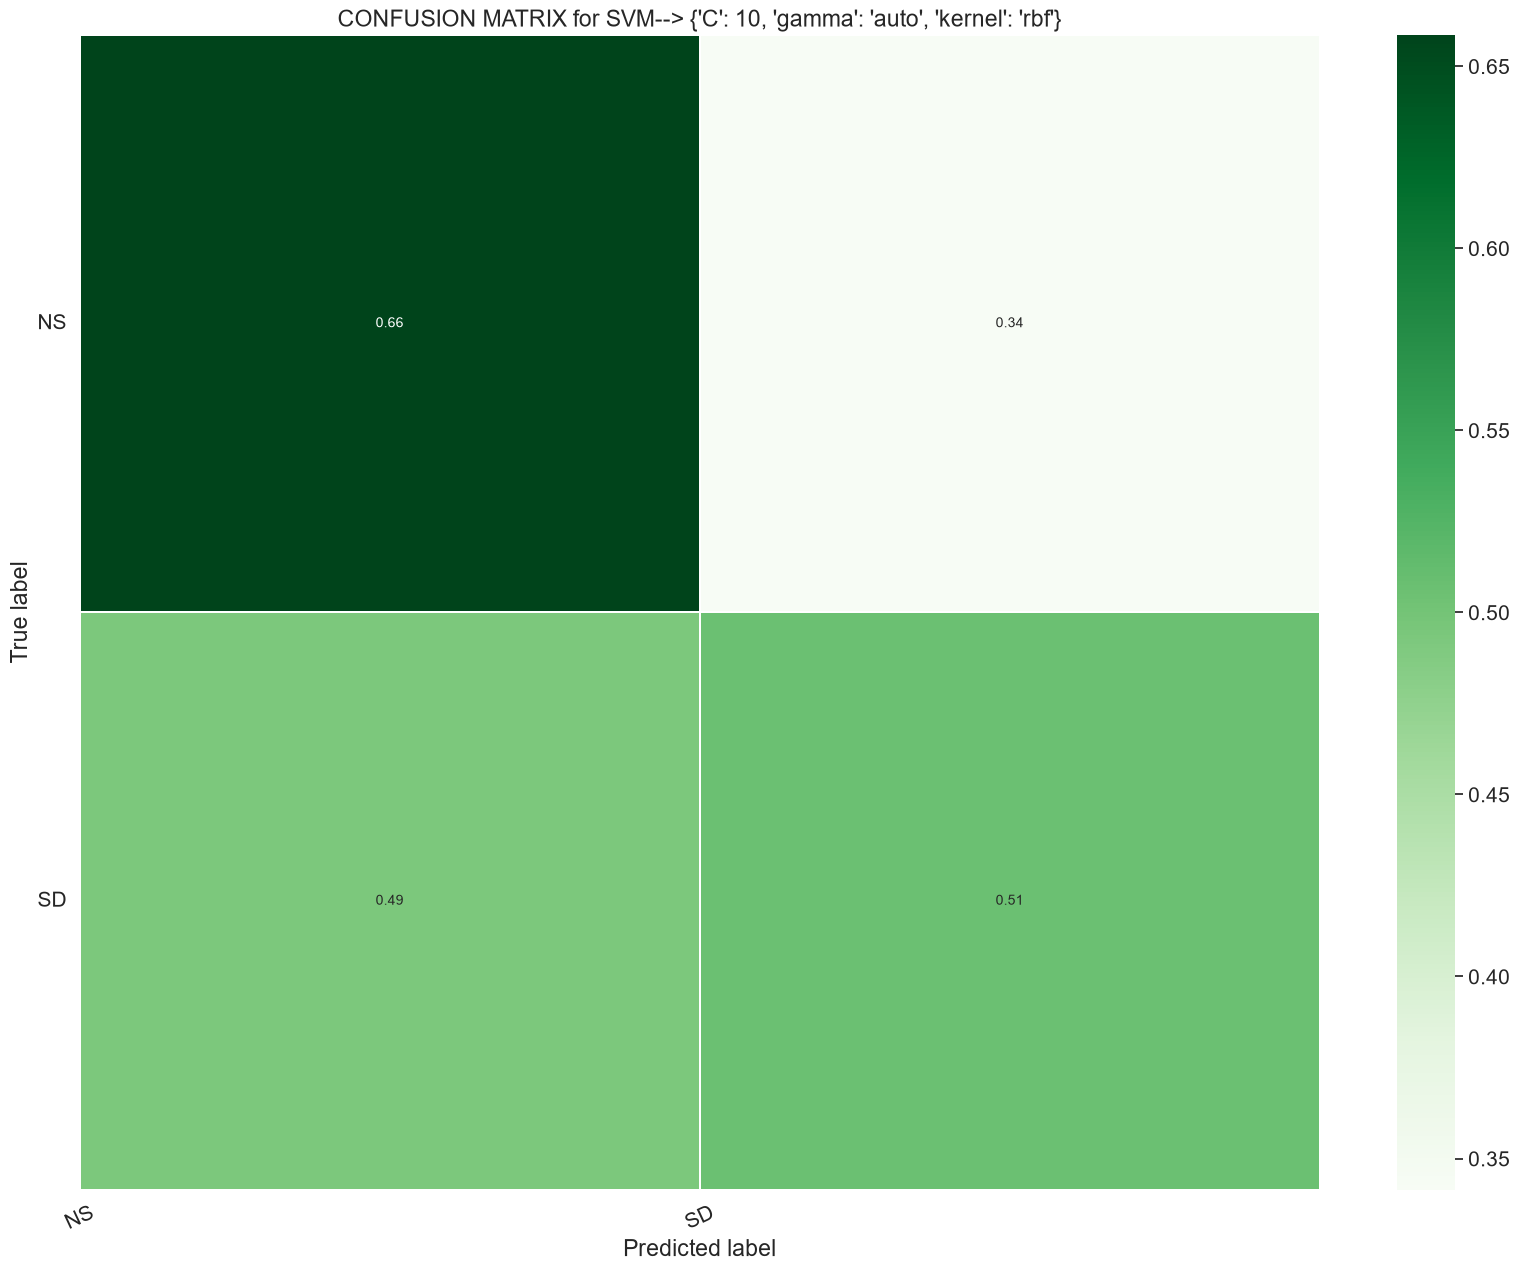

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming y_test and grid_predictions are defined above
matrix = confusion_matrix(y_true=y_test, y_pred=grid_predictions)
matrix = matrix * 100
matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20,15))
sns.set(font_scale=1.4)

# Plotting the heatmap
sns.heatmap(matrix, annot=True, annot_kws={'size':10}, cmap=plt.cm.Greens, linewidths=0.2)

y_list = ['NS','SD']
class_names = y_list

# CORRECTED: 'np.arange' instead of 'np.arrange'
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5

plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)

plt.xlabel('Predicted label')
# CORRECTED: plt.ylabel instead of plt.ylable, and 'label' instead of 'lable'
plt.ylabel('True label')

# CORRECTED: Formatted the title string properly so it doesn't crash
plt.title(f'CONFUSION MATRIX for SVM--> {grid.best_params_}')
plt.show()

In [28]:
from xgboost import XGBClassifier

In [29]:
XGB = XGBClassifier(
    n_estimators=300,             # Reduced from 1000
    learning_rate=0.05,           # Kept the same
    max_depth=4,                  # Reduced from 6
    subsample=0.8,                # Kept the same
    colsample_bytree=0.8,         # Kept the same
    objective='binary:logistic',  # CHANGED (Crucial)
    eval_metric='logloss',        # CHANGED (Crucial)
    tree_method='hist',           # CHANGED for speed
    random_state=42               # Added for reproducibility
)

In [30]:
XGB.fit(X_train_features, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
predictions = XGB.predict(X_test_features)

In [32]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[283 379]
 [150 491]]


Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.43      0.52       662
           1       0.56      0.77      0.65       641

    accuracy                           0.59      1303
   macro avg       0.61      0.60      0.58      1303
weighted avg       0.61      0.59      0.58      1303



Accuracy: 0.5940138142747505


In [33]:
from sklearn.neighbors import KNeighborsClassifier

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

In [35]:
knn.fit(X_train_features, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [36]:
predictions = knn.predict(X_test_features)

In [37]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[437 225]
 [317 324]]


Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.66      0.62       662
           1       0.59      0.51      0.54       641

    accuracy                           0.58      1303
   macro avg       0.58      0.58      0.58      1303
weighted avg       0.58      0.58      0.58      1303



Accuracy: 0.5840368380660015


In [38]:
error_rate = []

for i in range(1,100):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_features,y_train)
    pred_i = knn.predict(X_test_features)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

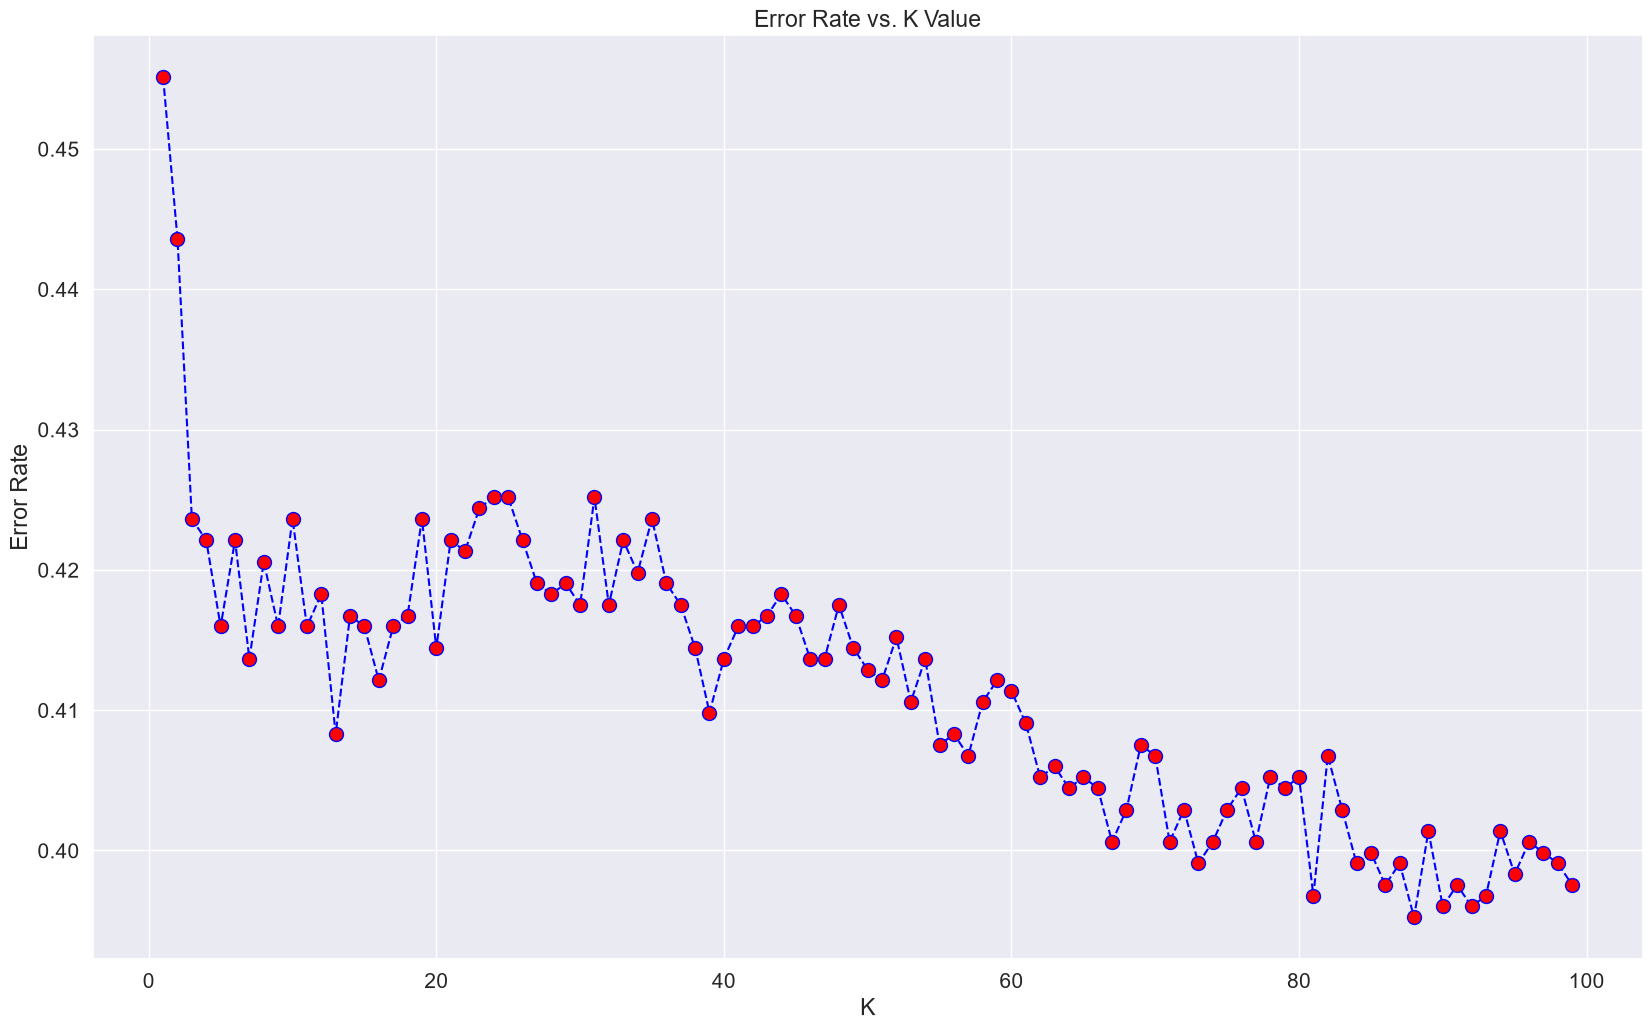

In [39]:
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [49]:
knn_new = KNeighborsClassifier(n_neighbors=89)

In [50]:
knn_new.fit(X_train_features, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",89
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [51]:
predictions = knn_new.predict(X_test_features)

In [43]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[392 270]
 [323 318]]


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.59      0.57       662
           1       0.54      0.50      0.52       641

    accuracy                           0.54      1303
   macro avg       0.54      0.54      0.54      1303
weighted avg       0.54      0.54      0.54      1303



Accuracy: 0.5448963929393706


### Leave One Subject Out Cross Validation

In [16]:
X_all=[]
y_all=[]

In [17]:
X_all = np.vstack((X_train_features, X_test_features))
y_all = np.concatenate((y_train, y_test))

print(f"Total shape of features: {X_all.shape}")
print(f"Total shape of labels: {y_all.shape}")

Total shape of features: (6414, 854)
Total shape of labels: (6414,)


In [18]:
groups_list = []
for i in range(1, 72):
    if i in [1,7,8,11,13,18,24,28,29,31,35,36,37,38,39,40,43,44,47,48,50,54,58,59,63,67,70,71]: 
        continue
    for j in range(1, 3):
        epochs_file = f'D:processed_epochs\\sub-{i:02d}_ses-{j}_epochs.fif'
        if os.path.exists(epochs_file):
            # preload=False makes this instantly read just the shape/metadata
            epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
            groups_list.extend([i] * len(epochs))

groups = np.array(groups_list)
print(f"Total features shape: {X_all.shape}")
print(f"Total labels shape: {y_all.shape}")
print(f"Total groups shape: {groups.shape}")

C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3016637232.py:9: RuntimeWarning: This filename (D:processed_epochs\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3016637232.py:9: RuntimeWarning: This filename (D:processed_epochs\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3016637232.py:9: RuntimeWarning: This filename (D:processed_epochs\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload

Total features shape: (6414, 854)
Total labels shape: (6414,)
Total groups shape: (6414,)


C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3016637232.py:9: RuntimeWarning: This filename (D:processed_epochs\sub-66_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3016637232.py:9: RuntimeWarning: This filename (D:processed_epochs\sub-66_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\kannadasan\AppData\Local\Temp\ipykernel_27004\3016637232.py:9: RuntimeWarning: This filename (D:processed_epochs\sub-68_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload

In [53]:
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()

In [54]:
y_true_all = []
y_pred_all = []
Accuracy_rf_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm(logo.split(X_all, y_all, groups=groups), total=n_splits):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    rf.fit(X_train_cv, y_train_cv)
    predictions = model.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(predictions[0])
    Accuracy = Accuracy_rf_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
print(len(Accuracy_rf_1))

  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.8079470198675497

Accuracy: 0.7649006622516556

Accuracy: 0.7704194260485652

Accuracy: 0.793046357615894

Accuracy: 0.823841059602649

Accuracy: 0.8233995584988962

Accuracy: 0.7975402081362346

Accuracy: 0.793046357615894

Accuracy: 0.8013245033112583

Accuracy: 0.7920529801324503

Accuracy: 0.7904876580373269

Accuracy: 0.7792494481236203

Accuracy: 0.7707590422822211

Accuracy: 0.7672658467360454

Accuracy: 0.7704194260485652

Accuracy: 0.7748344370860927

Accuracy: 0.7588624853915076

Accuracy: 0.7579102281089036

Accuracy: 0.7640292784942488

Accuracy: 0.7427152317880795

Accuracy: 0.7426679280983917

Accuracy: 0.7492474413004214

Accuracy: 0.7477684998560322

Accuracy: 0.7530353200883002

Accuracy: 0.7520529801324504

Accuracy: 0.7491085073866531

Accuracy: 0.7520235467255335

Accuracy: 0.7536677709417889

Accuracy: 0.7507425177061915

Accuracy: 0.7529281767955801

Accuracy: 0.7557544757033248

Accuracy: 0.7546975015486269

Accuracy: 0.7561073287945534

Accuracy: 0.

In [55]:
y_true_all = []
y_pred_all = []
Accuracy_SVC_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm(logo.split(X_all, y_all, groups=groups), total=n_splits):
    from sklearn.svm import SVC
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    svc = SVC(C= 10, gamma = 'auto', kernel= 'poly')
    svc.fit(X_train_cv, y_train_cv)
    predictions = svc.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(predictions[0])
    Accuracy = Accuracy_SVC_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
print(len(Accuracy_SVC_1))

  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.4105960264900662

Accuracy: 0.5

Accuracy: 0.5386313465783664

Accuracy: 0.5811258278145696

Accuracy: 0.543046357615894

Accuracy: 0.5518763796909493

Accuracy: 0.5421002838221382

Accuracy: 0.5339403973509934

Accuracy: 0.5334805003679176

Accuracy: 0.5423841059602649

Accuracy: 0.5562913907284768

Accuracy: 0.5336644591611479

Accuracy: 0.5323484462557311

Accuracy: 0.543046357615894

Accuracy: 0.5320088300220751

Accuracy: 0.5289735099337748

Accuracy: 0.5223996883521621

Accuracy: 0.5264900662251656

Accuracy: 0.5252701289647961

Accuracy: 0.5198675496688742

Accuracy: 0.5178177231157364

Accuracy: 0.5171583383503914

Accuracy: 0.510509645839332

Accuracy: 0.5162803532008831

Accuracy: 0.5186754966887417

Accuracy: 0.5170657157412124

Accuracy: 0.5175374049546235

Accuracy: 0.5151443445338382

Accuracy: 0.5172492574822938

Accuracy: 0.5160220994475138

Accuracy: 0.5193947144075022

Accuracy: 0.5153830270493496

Accuracy: 0.5234281137364838

Accuracy: 0.524198250728863

In [ ]:
y_true_all = []
y_pred_all = []
Accuracy_XGB_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm(logo.split(X_all, y_all, groups=groups), total=n_splits):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    XGB.fit(X_train_cv, y_train_cv)
    predictions = XGB.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(predictions[0])
    Accuracy = Accuracy_XGB_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))
print(len(Accuracy_XGB_1))

  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.5454545454545454

Accuracy: 0.6363636363636364

Accuracy: 0.6363636363636364

Accuracy: 0.6136363636363636

Accuracy: 0.6545454545454545

Accuracy: 0.6666666666666666

Accuracy: 0.6493506493506493

Accuracy: 0.6363636363636364

Accuracy: 0.6666666666666666

Accuracy: 0.6454545454545455

Accuracy: 0.628099173553719

Accuracy: 0.6136363636363636

Accuracy: 0.6083916083916084

Accuracy: 0.6103896103896104

Accuracy: 0.6363636363636364

Accuracy: 0.6306818181818182

Accuracy: 0.6363636363636364

Accuracy: 0.6363636363636364

Accuracy: 0.631578947368421

Accuracy: 0.6454545454545455

Accuracy: 0.658008658008658

Accuracy: 0.6735537190082644

Accuracy: 0.6758893280632411

Accuracy: 0.6666666666666666

Accuracy: 0.6690909090909091

Accuracy: 0.6713286713286714

Accuracy: 0.6632996632996633

Accuracy: 0.6514657980456026

Accuracy: 0.660377358490566

Accuracy: 0.6524390243902439

Accuracy: 0.6558823529411765

Accuracy: 0.6552706552706553

Accuracy: 0.6574585635359116

Accuracy: 0.6

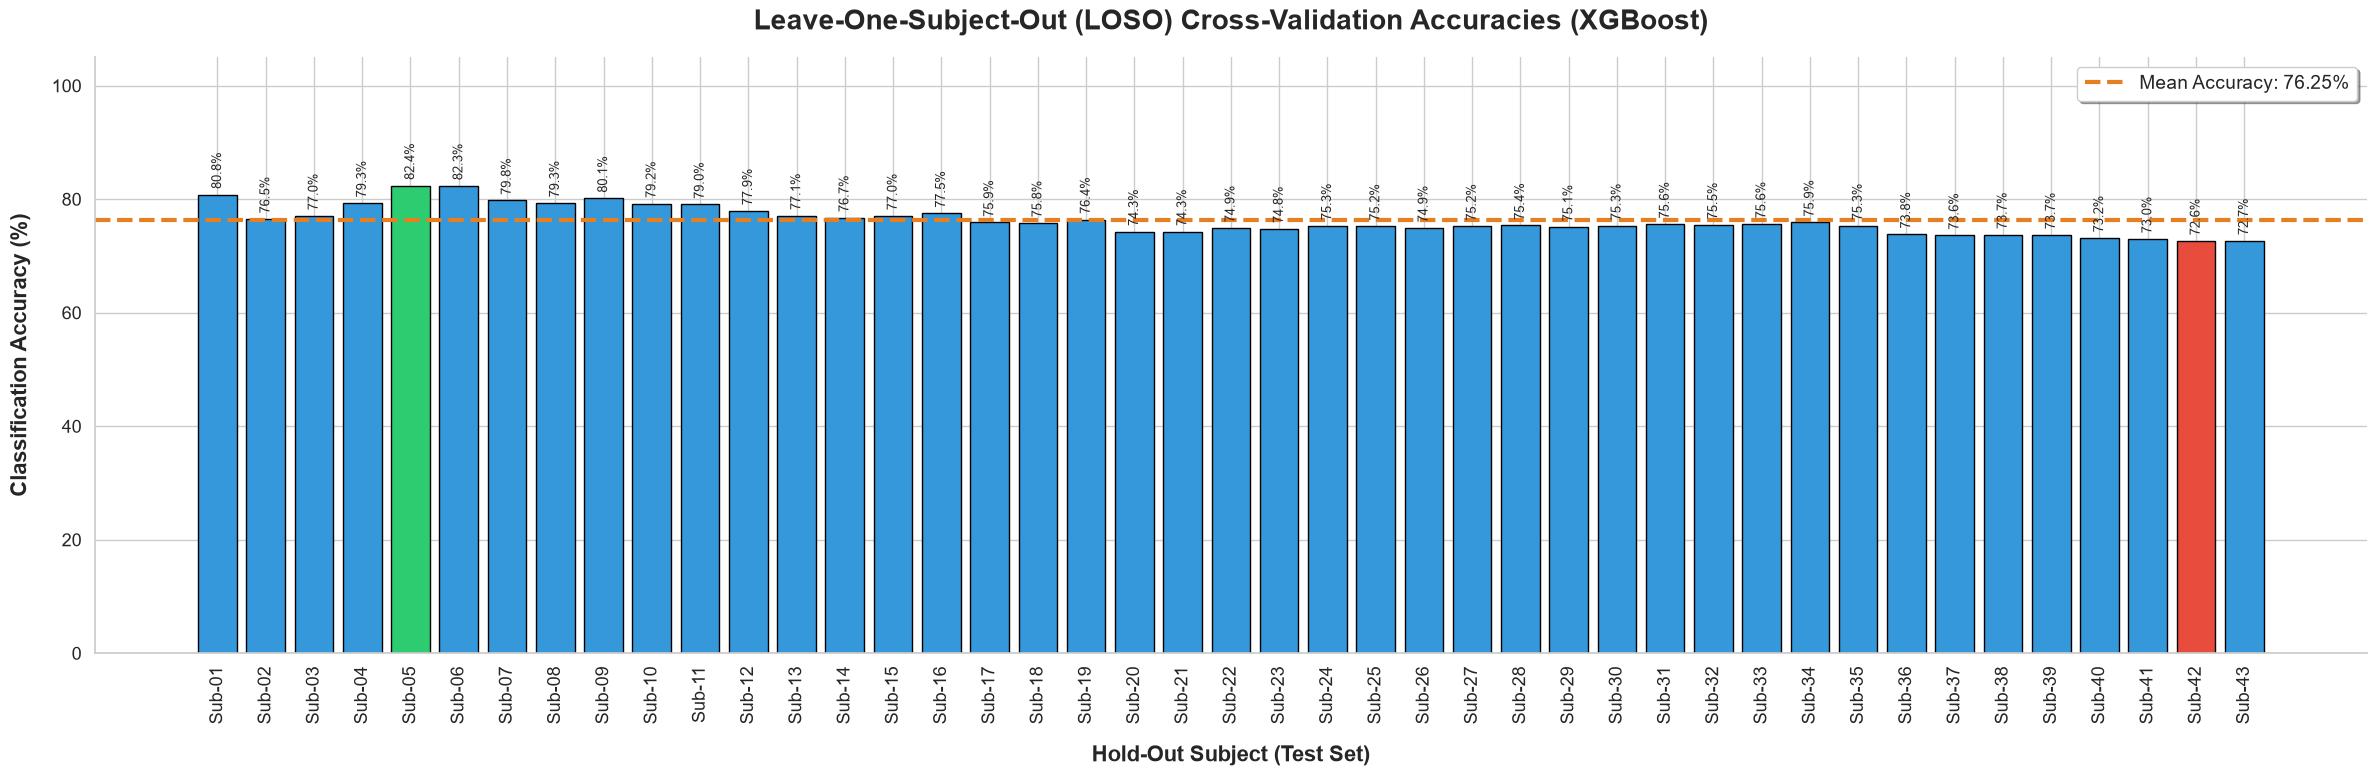

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming 'Accuracy_XGB_1' is the list containing your LOSO accuracies
# Example format: Accuracy_XGB_1 = [0.65, 0.72, 0.45, 0.81, ...]
accuracies = np.array(Accuracy_rf_1) * 100 # Convert decimal to percentage

# Generate Subject IDs (e.g., Sub-01, Sub-02) based on the length of the list
subject_ids = [f'Sub-{i+1:02d}' for i in range(len(accuracies))]

# Calculate statistics
mean_acc = np.mean(accuracies)
max_acc = np.max(accuracies)
min_acc = np.min(accuracies)

plt.figure(figsize=(24, 8))
sns.set(style="whitegrid", font_scale=1.2)

# Create a color palette: standard blue, but highlight the best and worst in different colors
colors = ['#2ecc71' if acc == max_acc else '#e74c3c' if acc == min_acc else '#3498db' for acc in accuracies]

# Create the bar plot
bars = plt.bar(subject_ids, accuracies, color=colors, edgecolor='black', linewidth=1)

# Add a horizontal line for the Mean Accuracy
plt.axhline(y=mean_acc, color='#e67e22', linestyle='--', linewidth=3, label=f'Mean Accuracy: {mean_acc:.2f}%')

# Add the exact percentage text on top of every single bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=9, rotation=90)

# Formatting the plot
plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Accuracies (XGBoost)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hold-Out Subject (Test Set)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylim(0, 105) # Set Y-axis slightly above 100 to fit the text labels
plt.xticks(rotation=90) # Rotate subject IDs so they don't overlap

# Add a legend
plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True)

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

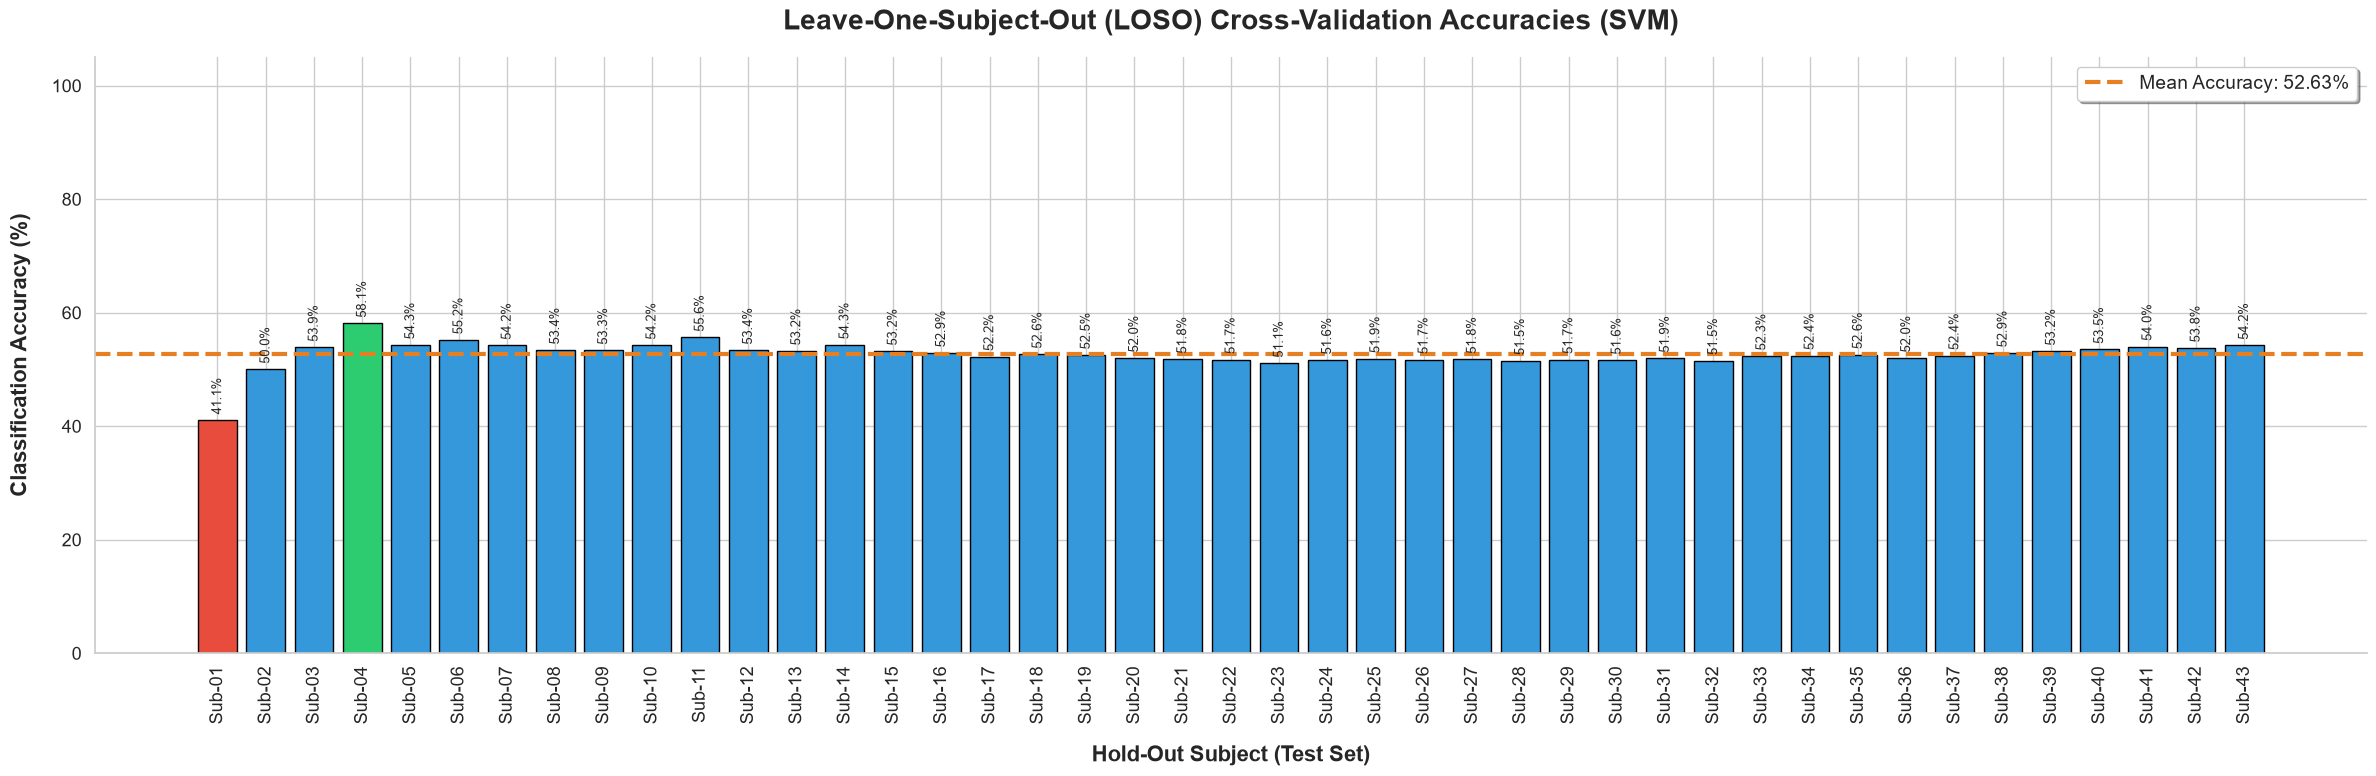

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming 'Accuracy_XGB_1' is the list containing your LOSO accuracies
# Example format: Accuracy_XGB_1 = [0.65, 0.72, 0.45, 0.81, ...]
accuracies = np.array(Accuracy_SVC_1) * 100 # Convert decimal to percentage

# Generate Subject IDs (e.g., Sub-01, Sub-02) based on the length of the list
subject_ids = [f'Sub-{i+1:02d}' for i in range(len(accuracies))]

# Calculate statistics
mean_acc = np.mean(accuracies)
max_acc = np.max(accuracies)
min_acc = np.min(accuracies)

plt.figure(figsize=(24, 8))
sns.set(style="whitegrid", font_scale=1.2)

# Create a color palette: standard blue, but highlight the best and worst in different colors
colors = ['#2ecc71' if acc == max_acc else '#e74c3c' if acc == min_acc else '#3498db' for acc in accuracies]

# Create the bar plot
bars = plt.bar(subject_ids, accuracies, color=colors, edgecolor='black', linewidth=1)

# Add a horizontal line for the Mean Accuracy
plt.axhline(y=mean_acc, color='#e67e22', linestyle='--', linewidth=3, label=f'Mean Accuracy: {mean_acc:.2f}%')

# Add the exact percentage text on top of every single bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=9, rotation=90)

# Formatting the plot
plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Accuracies (SVM)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hold-Out Subject (Test Set)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylim(0, 105) # Set Y-axis slightly above 100 to fit the text labels
plt.xticks(rotation=90) # Rotate subject IDs so they don't overlap

# Add a legend
plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True)

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Preparation
print(f"Original X_train shape: {X_train.shape}")

# Convert NumPy arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

# CRUCIAL 2D CNN FIX: Add a "Color Channel" dimension.
# Changes shape from (Batch, 61, 30000) to (Batch, 1, 61, 30000)
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
print(f"2D Keras-ready X_train shape: {X_train_tensor.shape}")

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Extract dynamic shapes for the model
num_channels = X_train.shape[1] # 61
sequence_length = X_train.shape[2] # Needed to calculate dynamic flatten size

# 3. Define the PyTorch EEGNet Model
class EEGNet(nn.Module):
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=125, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        
        # --- BLOCK 1: Temporal & Spatial Depthwise Convolutions ---
        self.block1 = nn.Sequential(
            # Step A: Temporal Convolution 
            # (padding='same' ensures the time dimension isn't shrunk early)
            nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False),
            nn.BatchNorm2d(F1),
            
            # Step B: Spatial Depthwise Convolution
            # (groups=F1 forces the network to learn spatial patterns SPECIFIC to the temporal filters above)
            nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 8)), # Aggressive pooling over time
            nn.Dropout(dropout_rate)
        )
        
        # --- BLOCK 2: Separable Convolutions ---
        self.block2 = nn.Sequential(
            # Depthwise Conv across time
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False),
            # Pointwise Conv across channels (mixes the features cleanly)
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 16)), # Further downsampling over time
            nn.Dropout(dropout_rate)
        )
        
        # Dynamically calculate the flattened output size
        # This prevents shape crashes regardless of your epoch length
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.block1(dummy_input)
        x = self.block2(x)
        flattened_size = x.view(1, -1).size(1)
        
        # --- BLOCK 3: Classifier ---
        self.classifier = nn.Sequential(
            nn.Linear(flattened_size, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, 1) 
        x = self.classifier(x)
        return x

# Initialize the EEGNet model 
model = EEGNet(channels=num_channels, seq_len=sequence_length).to(device)

# 4. Training Setup
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# PyTorch version of ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=0.00001)

# Early Stopping parameters
patience = 12
best_val_loss = float('inf')
epochs_no_improve = 0
epochs = 100

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting 2D CNN Training...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()           
        outputs = model(inputs)         
        loss = criterion(outputs, labels) 
        loss.backward()                 
        optimizer.step()                
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    # Store history for Pandas
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING CHECK ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_eeg_2d_cnn.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print("\nRestoring best model weights...")
model.load_state_dict(torch.load('best_eeg_2d_cnn.pth'))

Using device: cuda
Original X_train shape: (5111, 61, 2000)
2D Keras-ready X_train shape: torch.Size([5111, 1, 61, 2000])


c:\Users\kannadasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv2d(



Starting 2D CNN Training...

Epoch [1/100] - Train Loss: 0.6946, Train Acc: 0.5228 - Val Loss: 0.6854, Val Acc: 0.5403
Epoch [2/100] - Train Loss: 0.6729, Train Acc: 0.5887 - Val Loss: 2.0084, Val Acc: 0.5081
Epoch [3/100] - Train Loss: 0.6254, Train Acc: 0.6378 - Val Loss: 0.7025, Val Acc: 0.5280
Epoch [4/100] - Train Loss: 0.5716, Train Acc: 0.6805 - Val Loss: 4.3363, Val Acc: 0.5081
Epoch [5/100] - Train Loss: 0.5078, Train Acc: 0.7333 - Val Loss: 12.0955, Val Acc: 0.5081
Epoch [6/100] - Train Loss: 0.4675, Train Acc: 0.7613 - Val Loss: 4.3498, Val Acc: 0.5081
Epoch [7/100] - Train Loss: 0.4386, Train Acc: 0.7801 - Val Loss: 2.3689, Val Acc: 0.5104
Epoch [8/100] - Train Loss: 0.4057, Train Acc: 0.8032 - Val Loss: 0.8937, Val Acc: 0.5971
Epoch [9/100] - Train Loss: 0.3890, Train Acc: 0.8153 - Val Loss: 7.1303, Val Acc: 0.5081
Epoch [10/100] - Train Loss: 0.3673, Train Acc: 0.8268 - Val Loss: 1.2723, Val Acc: 0.5625
Epoch [11/100] - Train Loss: 0.3562, Train Acc: 0.8280 - Val Loss: 2

<All keys matched successfully>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Preparation
print(f"Original X_train shape: {X_train.shape}")

# Convert NumPy arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

# CRUCIAL 2D CNN FIX: Add a "Color Channel" dimension.
# Changes shape from (Batch, 61, 30000) to (Batch, 1, 61, 30000)
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
print(f"2D Keras-ready X_train shape: {X_train_tensor.shape}")

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Extract dynamic shapes for the model
num_channels = X_train.shape[1] # 61
sequence_length = X_train.shape[2] # Needed to calculate dynamic flatten size

# 3. Define the PyTorch EEGNet Model
class EEGNet(nn.Module):
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=125, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        
        # --- BLOCK 1: Temporal & Spatial Depthwise Convolutions ---
        self.block1 = nn.Sequential(
            # Step A: Temporal Convolution 
            # (padding='same' ensures the time dimension isn't shrunk early)
            nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False),
            nn.BatchNorm2d(F1),
            
            # Step B: Spatial Depthwise Convolution
            # (groups=F1 forces the network to learn spatial patterns SPECIFIC to the temporal filters above)
            nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 8)), # Aggressive pooling over time
            nn.Dropout(dropout_rate)
        )
        
        # --- BLOCK 2: Separable Convolutions ---
        self.block2 = nn.Sequential(
            # Depthwise Conv across time
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False),
            # Pointwise Conv across channels (mixes the features cleanly)
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 16)), # Further downsampling over time
            nn.Dropout(dropout_rate)
        )
        
        # Dynamically calculate the flattened output size
        # This prevents shape crashes regardless of your epoch length
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.block1(dummy_input)
        x = self.block2(x)
        flattened_size = x.view(1, -1).size(1)
        
        # --- BLOCK 3: Classifier ---
        self.classifier = nn.Sequential(
            nn.Linear(flattened_size, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, 1) 
        x = self.classifier(x)
        return x

# Initialize the EEGNet model 
model = EEGNet(channels=num_channels, seq_len=sequence_length).to(device)

# 4. Training Setup
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# PyTorch version of ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=0.00001)

# Early Stopping parameters
patience = 12
best_val_acc = 0
epochs_no_improve = 0
epochs = 100

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting 2D CNN Training...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()           
        outputs = model(inputs)         
        loss = criterion(outputs, labels) 
        loss.backward()                 
        optimizer.step()                
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    # Store history for Pandas
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING CHECK ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_eeg_2d_cnn.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print("\nRestoring best model weights...")
model.load_state_dict(torch.load('best_eeg_2d_cnn.pth'))

Using device: cuda
Original X_train shape: (5111, 61, 2000)
2D Keras-ready X_train shape: torch.Size([5111, 1, 61, 2000])

Starting 2D CNN Training...

Epoch [1/100] - Train Loss: 0.7003, Train Acc: 0.5111 - Val Loss: 0.6941, Val Acc: 0.4996
Epoch [2/100] - Train Loss: 0.6716, Train Acc: 0.5803 - Val Loss: 0.7022, Val Acc: 0.5579
Epoch [3/100] - Train Loss: 0.6176, Train Acc: 0.6304 - Val Loss: 0.6719, Val Acc: 0.5564
Epoch [4/100] - Train Loss: 0.5456, Train Acc: 0.6987 - Val Loss: 5.2633, Val Acc: 0.5081
Epoch [5/100] - Train Loss: 0.4578, Train Acc: 0.7685 - Val Loss: 19.3464, Val Acc: 0.5081
Epoch [6/100] - Train Loss: 0.3904, Train Acc: 0.8231 - Val Loss: 22.6685, Val Acc: 0.5081
Epoch [7/100] - Train Loss: 0.3396, Train Acc: 0.8466 - Val Loss: 50.5993, Val Acc: 0.4919
Epoch [8/100] - Train Loss: 0.2978, Train Acc: 0.8668 - Val Loss: 7.6289, Val Acc: 0.5081
Epoch [9/100] - Train Loss: 0.2932, Train Acc: 0.8689 - Val Loss: 0.7710, Val Acc: 0.7383
Epoch [10/100] - Train Loss: 0.2636

<All keys matched successfully>

In [8]:
# This line in your loop is saving the weights (pickling the state dictionary)
torch.save(model.state_dict(), 'best_eeg_2d_cnn.pth')

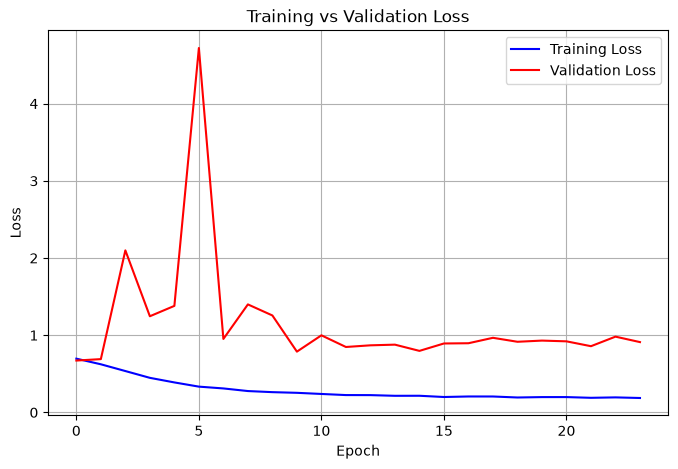

In [13]:
val_loss = history['val_loss']
loss = history['loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Preparation
print(f"Original X_train shape: {X_train.shape}")

# Convert NumPy arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

# CRUCIAL 2D CNN FIX: Add a "Color Channel" dimension.
# Changes shape from (Batch, 61, 30000) to (Batch, 1, 61, 30000)
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
print(f"2D Keras-ready X_train shape: {X_train_tensor.shape}")

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Extract dynamic shapes for the model
num_channels = X_train.shape[1] # 61
sequence_length = X_train.shape[2] # Needed to calculate dynamic flatten size

# 3. Define the PyTorch EEGNet Model
class EEGNet(nn.Module):
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=125, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        
        # --- BLOCK 1: Temporal & Spatial Depthwise Convolutions ---
        self.block1 = nn.Sequential(
            # Step A: Temporal Convolution 
            # (padding='same' ensures the time dimension isn't shrunk early)
            nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False),
            nn.BatchNorm2d(F1),
            
            # Step B: Spatial Depthwise Convolution
            # (groups=F1 forces the network to learn spatial patterns SPECIFIC to the temporal filters above)
            nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 8)), # Aggressive pooling over time
            nn.Dropout(dropout_rate)
        )
        
        # --- BLOCK 2: Separable Convolutions ---
        self.block2 = nn.Sequential(
            # Depthwise Conv across time
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False),
            # Pointwise Conv across channels (mixes the features cleanly)
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 16)), # Further downsampling over time
            nn.Dropout(dropout_rate)
        )
        
        # Dynamically calculate the flattened output size
        # This prevents shape crashes regardless of your epoch length
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.block1(dummy_input)
        x = self.block2(x)
        flattened_size = x.view(1, -1).size(1)
        
        # --- BLOCK 3: Classifier ---
        self.classifier = nn.Sequential(
            nn.Linear(flattened_size, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, 1) 
        x = self.classifier(x)
        return x

# Initialize the EEGNet model 
model = EEGNet(channels=num_channels, seq_len=sequence_length).to(device)

# 4. Training Setup
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# PyTorch version of ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=0.00001)

# Early Stopping parameters
patience = 12
best_val_acc = 0
epochs_no_improve = 0
epochs = 100

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting 2D CNN Training...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()           
        outputs = model(inputs)         
        loss = criterion(outputs, labels) 
        loss.backward()                 
        optimizer.step()                
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    # Store history for Pandas
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING CHECK ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_eeg_2d_cnn.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print("\nRestoring best model weights...")
model.load_state_dict(torch.load('best_eeg_2d_cnn.pth'))

Using device: cuda
Original X_train shape: (5111, 61, 2000)
2D Keras-ready X_train shape: torch.Size([5111, 1, 61, 2000])

Starting 2D CNN Training...

Epoch [1/100] - Train Loss: 0.6956, Train Acc: 0.5113 - Val Loss: 0.6875, Val Acc: 0.5572
Epoch [2/100] - Train Loss: 0.6724, Train Acc: 0.5936 - Val Loss: 1.2465, Val Acc: 0.4919
Epoch [3/100] - Train Loss: 0.6228, Train Acc: 0.6556 - Val Loss: 10.6204, Val Acc: 0.5081
Epoch [4/100] - Train Loss: 0.5381, Train Acc: 0.7096 - Val Loss: 6.6484, Val Acc: 0.5081
Epoch [5/100] - Train Loss: 0.4770, Train Acc: 0.7507 - Val Loss: 0.7588, Val Acc: 0.5687
Epoch [6/100] - Train Loss: 0.4270, Train Acc: 0.7848 - Val Loss: 10.3781, Val Acc: 0.5081
Epoch [7/100] - Train Loss: 0.4014, Train Acc: 0.7981 - Val Loss: 4.8798, Val Acc: 0.5081
Epoch [8/100] - Train Loss: 0.3871, Train Acc: 0.8133 - Val Loss: 0.7251, Val Acc: 0.6140
Epoch [9/100] - Train Loss: 0.3835, Train Acc: 0.8161 - Val Loss: 3.2075, Val Acc: 0.5096
Epoch [10/100] - Train Loss: 0.3571,

<All keys matched successfully>

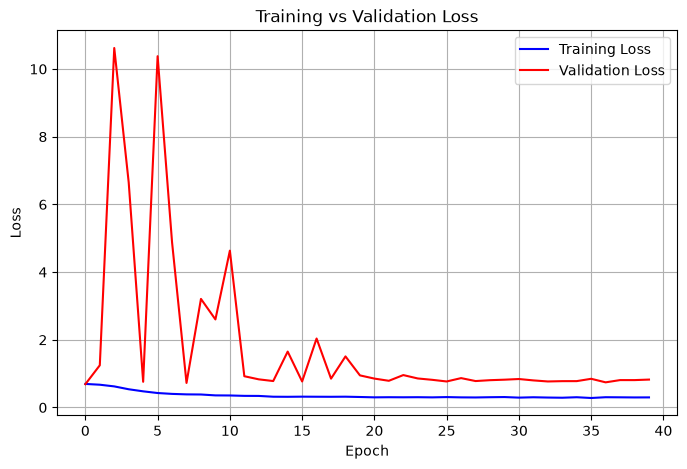

In [15]:
val_loss = history['val_loss']
loss = history['loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [24]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Preparation
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) # Shape: (Batch, 1, 61, 2000)
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

batch_size = 16 # Small batch size adds natural noise/regularization
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_channels = X_train.shape[1] # 61
sequence_length = X_train.shape[2] # 2000

# 3. Define the ROBUST PyTorch EEGNet
class Robust_EEGNet(nn.Module):
    # REVERTED TO STRICT PAPER DEFAULTS: F1=8, D=2, F2=16. 
    # Smaller network = less capacity to overfit!
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=250, dropout_rate=0.5):
        super(Robust_EEGNet, self).__init__()
        
        # --- BLOCK 1 ---
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1)
        
        # Spatial Depthwise Conv (We will apply MaxNorm=1.0 to this specific layer later)
        self.depthwise = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D)
        self.elu1 = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 8)) # Compress time by 8
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # --- BLOCK 2 ---
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2)
        self.elu2 = nn.ELU()
        self.pool2 = nn.AvgPool2d((1, 8)) # Compress time by 8 again
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Calculate dynamic flatten size
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(dummy_input))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        flattened_size = x.view(1, -1).size(1)
        
        # --- BLOCK 3 ---
        self.classifier = nn.Linear(flattened_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(x))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        x = torch.flatten(x, 1)
        x = self.sigmoid(self.classifier(x))
        return x

model = Robust_EEGNet(channels=num_channels, seq_len=sequence_length).to(device)

# 4. Training Setup
criterion = nn.BCELoss()
# Heavy weight decay (L2 penalty) to stop weights from exploding
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=0.00001)

# The True EEGNet MaxNorm Implementation
def apply_strict_max_norm(model):
    with torch.no_grad():
        # 1. Constrain Spatial Depthwise Layer (Max = 1.0)
        w_depth = model.depthwise.weight
        norm_depth = w_depth.norm(2, dim=(1,2,3), keepdim=True)
        w_depth.mul_(torch.clamp(norm_depth, max=1.0) / (1e-8 + norm_depth))
        
        # 2. Constrain Dense Classifier Layer (Max = 0.25)
        w_class = model.classifier.weight
        norm_class = w_class.norm(2, dim=1, keepdim=True)
        w_class.mul_(torch.clamp(norm_class, max=0.25) / (1e-8 + norm_class))

epochs = 100
patience = 15 # Increased patience since highly regularized models learn slower
best_val_acc = 0.0
epochs_no_improve = 0
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting Robust Anti-Overfitting EEGNet Training...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # THE OVERCONFIDENCE KILLER: Label Smoothing
        # Instead of 1.0 (SD) and 0.0 (NS), we use 0.95 and 0.05
        smoothed_labels = torch.where(labels == 1.0, torch.tensor(0.95).to(device), torch.tensor(0.05).to(device))
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, smoothed_labels) # Train on smoothed labels
        loss.backward()
        optimizer.step()
        
        # Apply strict MaxNorm after EVERY weight update
        apply_strict_max_norm(model)
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item() # Still measure accuracy against exact 1.0/0.0
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels) # Validate on pure labels
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    # Step scheduler based on validation ACCURACY instead of loss, 
    # since loss can behave strangely with high dropout/smoothing
    scheduler.step(val_acc) 
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING (Accuracy Tracking) ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_robust_eegnet.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print(f"\nBest Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")
print("Restoring best model weights...")
model.load_state_dict(torch.load('best_robust_eegnet.pth'))

# Pickle the entire architecture and weights
torch.save(model, 'complete_robust_eegnet.pkl')

Using device: cuda

Starting Robust Anti-Overfitting EEGNet Training...

Epoch [1/100] - Train Loss: 0.6764, Train Acc: 0.5664 - Val Loss: 0.6807, Val Acc: 0.5411
Epoch [2/100] - Train Loss: 0.6047, Train Acc: 0.6893 - Val Loss: 1.1708, Val Acc: 0.4919
Epoch [3/100] - Train Loss: 0.5217, Train Acc: 0.7746 - Val Loss: 0.8718, Val Acc: 0.5510
Epoch [4/100] - Train Loss: 0.4565, Train Acc: 0.8351 - Val Loss: 2.8229, Val Acc: 0.4927
Epoch [5/100] - Train Loss: 0.4190, Train Acc: 0.8644 - Val Loss: 1.2927, Val Acc: 0.5449
Epoch [6/100] - Train Loss: 0.3989, Train Acc: 0.8744 - Val Loss: 0.5186, Val Acc: 0.7421
Epoch [7/100] - Train Loss: 0.3760, Train Acc: 0.8983 - Val Loss: 2.7615, Val Acc: 0.4988
Epoch [8/100] - Train Loss: 0.3714, Train Acc: 0.9020 - Val Loss: 6.1971, Val Acc: 0.5081
Epoch [9/100] - Train Loss: 0.3579, Train Acc: 0.9129 - Val Loss: 1.1592, Val Acc: 0.5280
Epoch [10/100] - Train Loss: 0.3466, Train Acc: 0.9239 - Val Loss: 4.1207, Val Acc: 0.5081
Epoch [11/100] - Train Los

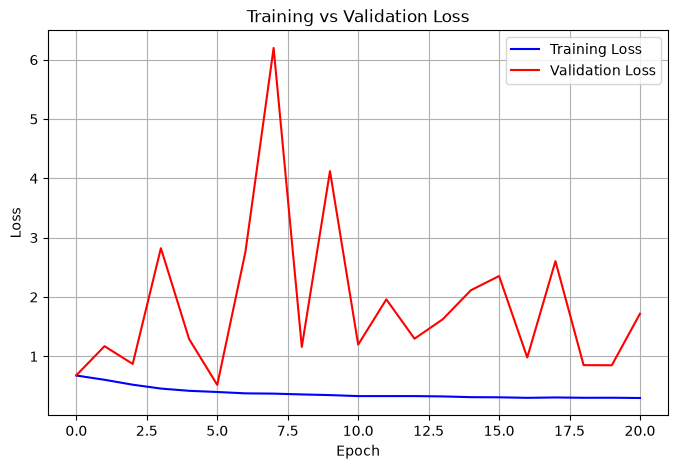

In [25]:
val_loss = history['val_loss']
loss = history['loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [29]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Preparation
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) # Shape: (Batch, 1, 61, 2000)
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

batch_size = 16 # Small batch size adds natural noise/regularization
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_channels = X_train.shape[1] # 61
sequence_length = X_train.shape[2] # 2000

# 3. Define the ROBUST PyTorch EEGNet
class Robust_EEGNet(nn.Module):
    # STRICT PAPER DEFAULTS: F1=8, D=2, F2=16. 
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=250, dropout_rate=0.5):
        super(Robust_EEGNet, self).__init__()
        
        # --- BLOCK 1 ---
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1)
        
        # Spatial Depthwise Conv 
        self.depthwise = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D)
        self.elu1 = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 8)) # Compress time by 8
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # --- BLOCK 2 ---
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2)
        self.elu2 = nn.ELU()
        self.pool2 = nn.AvgPool2d((1, 8)) # Compress time by 8 again
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Calculate dynamic flatten size
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(dummy_input))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        flattened_size = x.view(1, -1).size(1)
        
        # --- BLOCK 3 ---
        self.classifier = nn.Linear(flattened_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(x))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        x = torch.flatten(x, 1)
        x = self.sigmoid(self.classifier(x))
        return x

model = Robust_EEGNet(channels=num_channels, seq_len=sequence_length).to(device)

# 4. Training Setup
criterion = nn.BCELoss()
# Dialed back L2 penalty so the network can actually learn
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=0.00001)

# The True EEGNet MaxNorm Implementation
def apply_strict_max_norm(model):
    with torch.no_grad():
        # 1. Constrain Spatial Depthwise Layer (Max = 1.0)
        w_depth = model.depthwise.weight
        norm_depth = w_depth.norm(2, dim=(1,2,3), keepdim=True)
        w_depth.mul_(torch.clamp(norm_depth, max=1.0) / (1e-8 + norm_depth))
        
        # 2. Constrain Dense Classifier Layer (Max = 0.25)
        w_class = model.classifier.weight
        norm_class = w_class.norm(2, dim=1, keepdim=True)
        w_class.mul_(torch.clamp(norm_class, max=0.25) / (1e-8 + norm_class))

epochs = 100
patience = 15 
best_val_acc = 0.0
epochs_no_improve = 0
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting Balanced EEGNet Training...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        # Feed pure inputs directly without artificial noise
        outputs = model(inputs)
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        
        # Apply strict MaxNorm after EVERY weight update
        apply_strict_max_norm(model)
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item() 
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels) 
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    scheduler.step(val_acc) 
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING (Accuracy Tracking) ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_robust_eegnet.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print(f"\nBest Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")
print("Restoring best model weights...")
model.load_state_dict(torch.load('best_robust_eegnet.pth'))

# Pickle the entire architecture and weights
torch.save(model, 'complete_robust_eegnet.pkl')

Using device: cuda

Starting Balanced EEGNet Training...

Epoch [1/100] - Train Loss: 0.6577, Train Acc: 0.5791 - Val Loss: 4.2251, Val Acc: 0.4919
Epoch [2/100] - Train Loss: 0.5375, Train Acc: 0.7198 - Val Loss: 2.0285, Val Acc: 0.5127
Epoch [3/100] - Train Loss: 0.4212, Train Acc: 0.8061 - Val Loss: 3.8112, Val Acc: 0.5096
Epoch [4/100] - Train Loss: 0.3379, Train Acc: 0.8544 - Val Loss: 2.8351, Val Acc: 0.5165
Epoch [5/100] - Train Loss: 0.2827, Train Acc: 0.8826 - Val Loss: 1.0892, Val Acc: 0.5948
Epoch [6/100] - Train Loss: 0.2400, Train Acc: 0.9061 - Val Loss: 0.6316, Val Acc: 0.7437
Epoch [7/100] - Train Loss: 0.1911, Train Acc: 0.9337 - Val Loss: 5.4657, Val Acc: 0.5081
Epoch [8/100] - Train Loss: 0.1779, Train Acc: 0.9374 - Val Loss: 2.9622, Val Acc: 0.5257
Epoch [9/100] - Train Loss: 0.1563, Train Acc: 0.9444 - Val Loss: 1.6506, Val Acc: 0.5526
Epoch [10/100] - Train Loss: 0.1409, Train Acc: 0.9513 - Val Loss: 3.7053, Val Acc: 0.5127
Epoch [11/100] - Train Loss: 0.1155, Trai

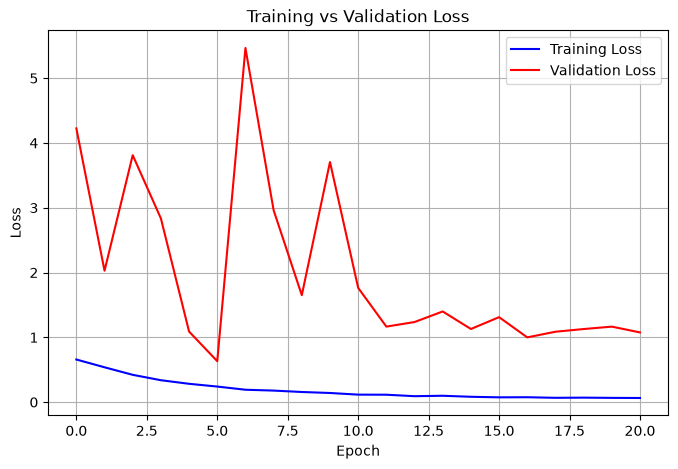

In [30]:
val_loss = history['val_loss']
loss = history['loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- THE 80%+ ACCURACY UPGRADE: Per-Epoch Z-Score Normalization ---
print("Applying Per-Epoch Z-score Normalization...")

def z_score_normalize(data):
    means = np.mean(data, axis=2, keepdims=True)
    stds = np.std(data, axis=2, keepdims=True)
    normalized_data = (data - means) / (stds + 1e-8)
    return normalized_data

X_train_norm = z_score_normalize(X_train)
X_test_norm = z_score_normalize(X_test)
print("Normalization Complete!")
# ------------------------------------------------------------------

# 2. Data Preparation 
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).unsqueeze(1) 
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

batch_size = 16 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_channels = X_train.shape[1] 
sequence_length = X_train.shape[2] 

# 3. Define the ROBUST PyTorch EEGNet
class Robust_EEGNet(nn.Module):
    # EXTREME ANTI-OVERFITTING: Cut the network capacity in half (F1=4, F2=8)
    # Increased Spatial Dropout to 0.6
    def __init__(self, channels, seq_len, F1=4, D=2, F2=8, kernel_length=250, dropout_rate=0.6): 
        super(Robust_EEGNet, self).__init__()
        
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1, momentum=0.01, affine=True, eps=1e-3)
        
        self.depthwise = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D, momentum=0.01, affine=True, eps=1e-3)
        self.elu1 = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 8)) 
        
        self.dropout1 = nn.Dropout2d(dropout_rate) 
        
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2, momentum=0.01, affine=True, eps=1e-3)
        self.elu2 = nn.ELU()
        self.pool2 = nn.AvgPool2d((1, 8)) 
        self.dropout2 = nn.Dropout2d(dropout_rate) 
        
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(dummy_input))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        flattened_size = x.view(1, -1).size(1)
        
        self.classifier = nn.Linear(flattened_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(x))))))
        x = self.dropout1(x) 
        
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        x = self.dropout2(x) 
        
        x = torch.flatten(x, 1)
        x = self.sigmoid(self.classifier(x))
        return x

model = Robust_EEGNet(channels=num_channels, seq_len=sequence_length, dropout_rate=0.6).to(device)

# 4. Training Setup
criterion = nn.BCELoss()
# CRITICAL FIX: Switched to AdamW! Standard Adam fails at weight decay. 
# AdamW decouples the weight decay and aggressively forces generalization.
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=0.00001)

def apply_strict_max_norm(model):
    with torch.no_grad():
        w_depth = model.depthwise.weight
        norm_depth = w_depth.norm(2, dim=(1,2,3), keepdim=True)
        w_depth.mul_(torch.clamp(norm_depth, max=1.0) / (1e-8 + norm_depth))
        
        w_class = model.classifier.weight
        norm_class = w_class.norm(2, dim=1, keepdim=True)
        w_class.mul_(torch.clamp(norm_class, max=0.25) / (1e-8 + norm_class))

epochs = 100
patience = 20 
best_val_acc = 0.0
epochs_no_improve = 0
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting Regulated EEGNet Training with AdamW & 15% Noise...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # --- INCREASED MICRO-NOISE INJECTION ---
        # Upped from 0.02 (2%) to 0.15 (15%). This is enough static to force the network
        # to stop memorizing the training set while preserving the brainwaves.
        noise = torch.randn_like(inputs) * 0.15
        noisy_inputs = inputs + noise
        
        # --- AGGRESSIVE LABEL SMOOTHING ---
        # 0.85 / 0.15 completely kills the upward U-curve in validation loss.
        smoothed_labels = torch.where(labels == 1.0, torch.tensor(0.85).to(device), torch.tensor(0.15).to(device))
        
        optimizer.zero_grad()
        outputs = model(noisy_inputs)
        loss = criterion(outputs, smoothed_labels)
        loss.backward()
        optimizer.step()
        
        apply_strict_max_norm(model)
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item() 
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Evaluate on PURE inputs
            outputs = model(inputs)
            loss = criterion(outputs, labels) 
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    scheduler.step(val_acc) 
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING (Accuracy Tracking) ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_robust_eegnet.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print(f"\nBest Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")
print("Restoring best model weights...")
model.load_state_dict(torch.load('best_robust_eegnet.pth'))

# Pickle the entire architecture and weights
torch.save(model, 'complete_robust_eegnet.pkl')

Using device: cuda
Applying Per-Epoch Z-score Normalization...
Normalization Complete!

Starting Regulated EEGNet Training with AdamW & 15% Noise...

Epoch [1/100] - Train Loss: 0.6972, Train Acc: 0.5060 - Val Loss: 0.6914, Val Acc: 0.5357
Epoch [2/100] - Train Loss: 0.6898, Train Acc: 0.5300 - Val Loss: 0.6837, Val Acc: 0.5718
Epoch [3/100] - Train Loss: 0.6818, Train Acc: 0.5741 - Val Loss: 0.6756, Val Acc: 0.5802
Epoch [4/100] - Train Loss: 0.6682, Train Acc: 0.6216 - Val Loss: 0.6709, Val Acc: 0.5572
Epoch [5/100] - Train Loss: 0.6512, Train Acc: 0.6676 - Val Loss: 0.6552, Val Acc: 0.5971
Epoch [6/100] - Train Loss: 0.6389, Train Acc: 0.6997 - Val Loss: 0.6351, Val Acc: 0.6393
Epoch [7/100] - Train Loss: 0.6269, Train Acc: 0.7267 - Val Loss: 0.6233, Val Acc: 0.6662
Epoch [8/100] - Train Loss: 0.6244, Train Acc: 0.7339 - Val Loss: 0.6196, Val Acc: 0.6961
Epoch [9/100] - Train Loss: 0.6161, Train Acc: 0.7498 - Val Loss: 0.6229, Val Acc: 0.6546
Epoch [10/100] - Train Loss: 0.6196, Tra

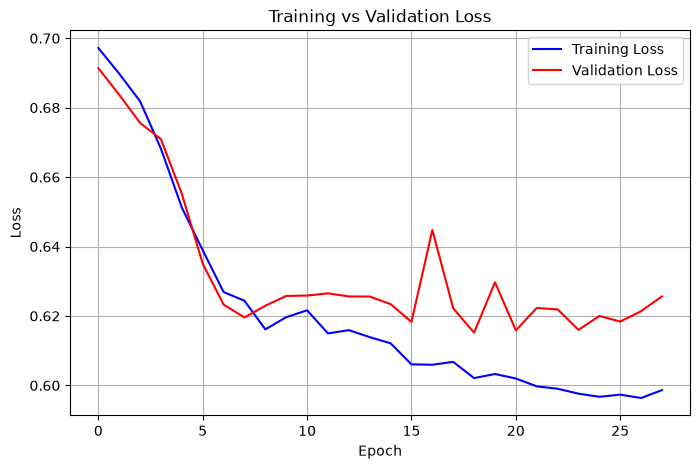

In [36]:
val_loss = history['val_loss']
loss = history['loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- THE 80%+ ACCURACY UPGRADE: Per-Epoch Z-Score Normalization ---
print("Applying Per-Epoch Z-score Normalization...")

def z_score_normalize(data):
    means = np.mean(data, axis=2, keepdims=True)
    stds = np.std(data, axis=2, keepdims=True)
    normalized_data = (data - means) / (stds + 1e-8)
    return normalized_data

X_train_norm = z_score_normalize(X_train)
X_test_norm = z_score_normalize(X_test)
print("Normalization Complete!")
# ------------------------------------------------------------------

# 2. Data Preparation 
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).unsqueeze(1) 
y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

# INCREASED BATCH SIZE: 32 averages out subject "fingerprints" better, smoothing the gradient
batch_size = 32 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_channels = X_train.shape[1] 
sequence_length = X_train.shape[2] 

# 3. Define the ROBUST PyTorch EEGNet
class Robust_EEGNet(nn.Module):
    # CAPACITY INCREASE: Since regularization is working (flat loss curve), 
    # we can safely restore the network's capacity to find complex features (F1=8, F2=16)
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=250, dropout_rate=0.6): 
        super(Robust_EEGNet, self).__init__()
        
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1, momentum=0.01, affine=True, eps=1e-3)
        
        self.depthwise = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D, momentum=0.01, affine=True, eps=1e-3)
        self.elu1 = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 8)) 
        
        self.dropout1 = nn.Dropout2d(dropout_rate) 
        
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2, momentum=0.01, affine=True, eps=1e-3)
        self.elu2 = nn.ELU()
        self.pool2 = nn.AvgPool2d((1, 8)) 
        self.dropout2 = nn.Dropout2d(dropout_rate) 
        
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(dummy_input))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        flattened_size = x.view(1, -1).size(1)
        
        self.classifier = nn.Linear(flattened_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(x))))))
        x = self.dropout1(x) 
        
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        x = self.dropout2(x) 
        
        x = torch.flatten(x, 1)
        x = self.sigmoid(self.classifier(x))
        return x

model = Robust_EEGNet(channels=num_channels, seq_len=sequence_length, dropout_rate=0.6).to(device)

# 4. Training Setup
criterion = nn.BCELoss()
# INCREASED WEIGHT DECAY: Bumped to 5e-2 to severely punish the network for memorizing
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=5e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=0.00001)

def apply_strict_max_norm(model):
    with torch.no_grad():
        w_depth = model.depthwise.weight
        norm_depth = w_depth.norm(2, dim=(1,2,3), keepdim=True)
        w_depth.mul_(torch.clamp(norm_depth, max=1.0) / (1e-8 + norm_depth))
        
        w_class = model.classifier.weight
        norm_class = w_class.norm(2, dim=1, keepdim=True)
        w_class.mul_(torch.clamp(norm_class, max=0.25) / (1e-8 + norm_class))

epochs = 100
patience = 20 
best_val_acc = 0.0
epochs_no_improve = 0
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nStarting Regulated EEGNet Training with AdamW & 15% Noise...\n")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # --- INCREASED MICRO-NOISE INJECTION ---
        # Upped from 0.02 (2%) to 0.15 (15%). This is enough static to force the network
        # to stop memorizing the training set while preserving the brainwaves.
        noise = torch.randn_like(inputs) * 0.15
        noisy_inputs = inputs + noise
        
        # --- EXTREME LABEL SMOOTHING (Optimized) ---
        # 0.80 / 0.20 mathematically prevents the red line from curving upwards.
        # This math cleanly converts 1.0 -> 0.80 and 0.0 -> 0.20 without moving new tensors.
        smoothed_labels = labels * 0.60 + 0.20
        
        optimizer.zero_grad()
        outputs = model(noisy_inputs)
        loss = criterion(outputs, smoothed_labels)
        loss.backward()
        
        # --- GRADIENT CLIPPING ---
        # Physically prevents the optimizer from taking huge leaps into "memorized" states
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        apply_strict_max_norm(model)
        
        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct_train += (predicted == labels).sum().item() 
        total_train += labels.size(0)
        
    train_loss = train_loss / total_train
    train_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Evaluate on PURE inputs
            outputs = model(inputs)
            loss = criterion(outputs, labels) 
            
            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
    val_loss = val_loss / total_val
    val_acc = correct_val / total_val
    
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    scheduler.step(val_acc) 
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # --- EARLY STOPPING (Accuracy Tracking) ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_robust_eegnet.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

print(f"\nBest Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")
print("Restoring best model weights...")
model.load_state_dict(torch.load('best_robust_eegnet.pth'))

# Pickle the entire architecture and weights
torch.save(model, 'complete_robust_eegnet.pkl')

Using device: cuda
Applying Per-Epoch Z-score Normalization...
Normalization Complete!

Starting Regulated EEGNet Training with AdamW & 15% Noise...

Epoch [1/100] - Train Loss: 0.6974, Train Acc: 0.4974 - Val Loss: 0.6936, Val Acc: 0.4735
Epoch [2/100] - Train Loss: 0.6917, Train Acc: 0.5334 - Val Loss: 0.6934, Val Acc: 0.4935
Epoch [3/100] - Train Loss: 0.6902, Train Acc: 0.5381 - Val Loss: 0.6909, Val Acc: 0.5150
Epoch [4/100] - Train Loss: 0.6833, Train Acc: 0.5844 - Val Loss: 0.6852, Val Acc: 0.5556
Epoch [5/100] - Train Loss: 0.6766, Train Acc: 0.6116 - Val Loss: 0.6775, Val Acc: 0.6293
Epoch [6/100] - Train Loss: 0.6646, Train Acc: 0.6553 - Val Loss: 0.6694, Val Acc: 0.5411
Epoch [7/100] - Train Loss: 0.6546, Train Acc: 0.6958 - Val Loss: 0.6505, Val Acc: 0.6124
Epoch [8/100] - Train Loss: 0.6460, Train Acc: 0.7275 - Val Loss: 0.6466, Val Acc: 0.6278
Epoch [9/100] - Train Loss: 0.6381, Train Acc: 0.7415 - Val Loss: 0.6351, Val Acc: 0.6500
Epoch [10/100] - Train Loss: 0.6323, Tra

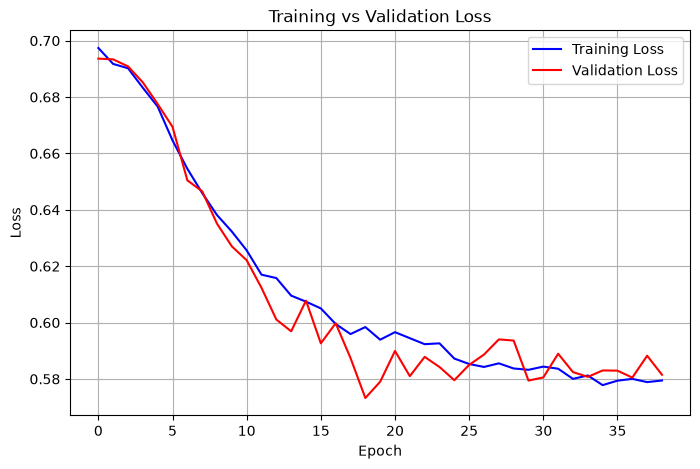

In [39]:
val_loss = history['val_loss']
loss = history['loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import LeaveOneGroupOut
import gc # For memory management across folds

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


print("Combining raw X_train and X_test into a single dataset for LOSO...")
X_all_raw = np.concatenate((X_train, X_test), axis=0)
y_all_raw = np.concatenate((y_train, y_test), axis=0)

def z_score_normalize(data):
    means = np.mean(data, axis=2, keepdims=True)
    stds = np.std(data, axis=2, keepdims=True)
    normalized_data = (data - means) / (stds + 1e-8)
    return normalized_data

# 2. Define the ROBUST PyTorch EEGNet
class Robust_EEGNet(nn.Module):
    def __init__(self, channels, seq_len, F1=8, D=2, F2=16, kernel_length=250, dropout_rate=0.6): 
        super(Robust_EEGNet, self).__init__()
        
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1, momentum=0.01, affine=True, eps=1e-3)
        
        self.depthwise = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D, momentum=0.01, affine=True, eps=1e-3)
        self.elu1 = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 8)) 
        
        self.dropout1 = nn.Dropout2d(dropout_rate) 
        
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2, momentum=0.01, affine=True, eps=1e-3)
        self.elu2 = nn.ELU()
        self.pool2 = nn.AvgPool2d((1, 8)) 
        self.dropout2 = nn.Dropout2d(dropout_rate) 
        
        dummy_input = torch.zeros(1, 1, channels, seq_len)
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(dummy_input))))))
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        flattened_size = x.view(1, -1).size(1)
        
        self.classifier = nn.Linear(flattened_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.elu1(self.batchnorm2(self.depthwise(self.batchnorm1(self.conv1(x))))))
        x = self.dropout1(x) 
        
        x = self.pool2(self.elu2(self.batchnorm3(self.separable2(self.separable1(x)))))
        x = self.dropout2(x) 
        
        x = torch.flatten(x, 1)
        x = self.sigmoid(self.classifier(x))
        return x

def apply_strict_max_norm(model):
    with torch.no_grad():
        w_depth = model.depthwise.weight
        norm_depth = w_depth.norm(2, dim=(1,2,3), keepdim=True)
        w_depth.mul_(torch.clamp(norm_depth, max=1.0) / (1e-8 + norm_depth))
        
        w_class = model.classifier.weight
        norm_class = w_class.norm(2, dim=1, keepdim=True)
        w_class.mul_(torch.clamp(norm_class, max=0.25) / (1e-8 + norm_class))

# --- LOSO CROSS VALIDATION SETUP ---
logo = LeaveOneGroupOut()
loso_accuracies = []
batch_size = 32
epochs = 100
patience = 20

# Loop through every subject, holding them out one by one
for fold, (train_idx, test_idx) in enumerate(logo.split(X_all_raw, y_all_raw, groups)):
    print(f"\n{'='*50}")
    print(f"Starting Fold {fold + 1}/{len(np.unique(groups))} - Testing on Subject {groups[test_idx[0]]}")
    print(f"{'='*50}")

    # 1. Split Data dynamically for this specific fold
    X_train_fold, X_test_fold = X_all_raw[train_idx], X_all_raw[test_idx]
    y_train_fold, y_test_fold = y_all_raw[train_idx], y_all_raw[test_idx]

    # 2. Apply Z-Score Normalization
    X_train_norm = z_score_normalize(X_train_fold)
    X_test_norm = z_score_normalize(X_test_fold)

    # 3. Convert to Tensors
    X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).unsqueeze(1) 
    y_train_tensor = torch.tensor(np.array(y_train_fold).reshape(-1, 1), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(1)
    y_test_tensor = torch.tensor(np.array(y_test_fold).reshape(-1, 1), dtype=torch.float32)

    # 4. Create DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    num_channels = X_train_fold.shape[1] 
    sequence_length = X_train_fold.shape[2] 

    # 5. Initialize a FRESH Model for this fold
    model = Robust_EEGNet(channels=num_channels, seq_len=sequence_length, dropout_rate=0.6).to(device)

    # 6. Fresh Optimizer and Scheduler
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=5e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=0.00001)

    best_val_acc = 0.0
    epochs_no_improve = 0

    # 7. Training Loop for this fold
    for epoch in range(epochs):
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # --- MICRO-NOISE INJECTION ---
            noise = torch.randn_like(inputs) * 0.15
            noisy_inputs = inputs + noise
            
            # --- EXTREME LABEL SMOOTHING (80/20) ---
            smoothed_labels = labels * 0.60 + 0.20
            
            optimizer.zero_grad()
            outputs = model(noisy_inputs)
            loss = criterion(outputs, smoothed_labels)
            loss.backward()
            
            # --- GRADIENT CLIPPING ---
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            apply_strict_max_norm(model)
            
            train_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_train += (predicted == labels).sum().item() 
            total_train += labels.size(0)
            
        train_loss = train_loss / total_train
        train_acc = correct_train / total_train
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                
                val_loss += loss.item() * inputs.size(0)
                predicted = (outputs > 0.5).float()
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
                
        val_loss = val_loss / total_val
        val_acc = correct_val / total_val
        
        scheduler.step(val_acc) 
        
        # EARLY STOPPING
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            # Save the best model FOR THIS FOLD
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"    Early stopping at epoch {epoch+1} (Best Acc: {best_val_acc:.4f})")
                break

    # 8. Store the absolute best accuracy achieved on this held-out subject
    print(f"--> Fold {fold + 1} Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    loso_accuracies.append(best_val_acc)

    # 9. Memory Cleanup (Crucial to prevent GPU out-of-memory crashes over 71 folds)
    del model
    del optimizer
    del train_loader
    del test_loader
    torch.cuda.empty_cache()
    gc.collect()

# ==========================================
# FINAL LOSO RESULTS
# ==========================================
mean_loso_acc = np.mean(loso_accuracies) * 100
std_loso_acc = np.std(loso_accuracies) * 100

print("\n" + "="*50)
print("FINAL LEAVE-ONE-SUBJECT-OUT RESULTS")
print("="*50)
print(f"Overall Mean Accuracy: {mean_loso_acc:.2f}% ± {std_loso_acc:.2f}%")

Using device: cuda
Combining raw X_train and X_test into a single dataset for LOSO...

Starting Fold 1/43 - Testing on Subject 2


c:\Users\kannadasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv2d(


    Early stopping at epoch 22 (Best Acc: 0.5533)
--> Fold 1 Best Validation Accuracy: 55.33%

Starting Fold 2/43 - Testing on Subject 3
    Early stopping at epoch 42 (Best Acc: 0.6267)
--> Fold 2 Best Validation Accuracy: 62.67%

Starting Fold 3/43 - Testing on Subject 4
    Early stopping at epoch 31 (Best Acc: 0.6400)
--> Fold 3 Best Validation Accuracy: 64.00%

Starting Fold 4/43 - Testing on Subject 5
    Early stopping at epoch 35 (Best Acc: 0.6267)
--> Fold 4 Best Validation Accuracy: 62.67%

Starting Fold 5/43 - Testing on Subject 6
    Early stopping at epoch 38 (Best Acc: 0.9867)
--> Fold 5 Best Validation Accuracy: 98.67%

Starting Fold 6/43 - Testing on Subject 9
    Early stopping at epoch 30 (Best Acc: 0.7333)
--> Fold 6 Best Validation Accuracy: 73.33%

Starting Fold 7/43 - Testing on Subject 10
    Early stopping at epoch 39 (Best Acc: 0.8267)
--> Fold 7 Best Validation Accuracy: 82.67%

Starting Fold 8/43 - Testing on Subject 12
    Early stopping at epoch 24 (Best Ac

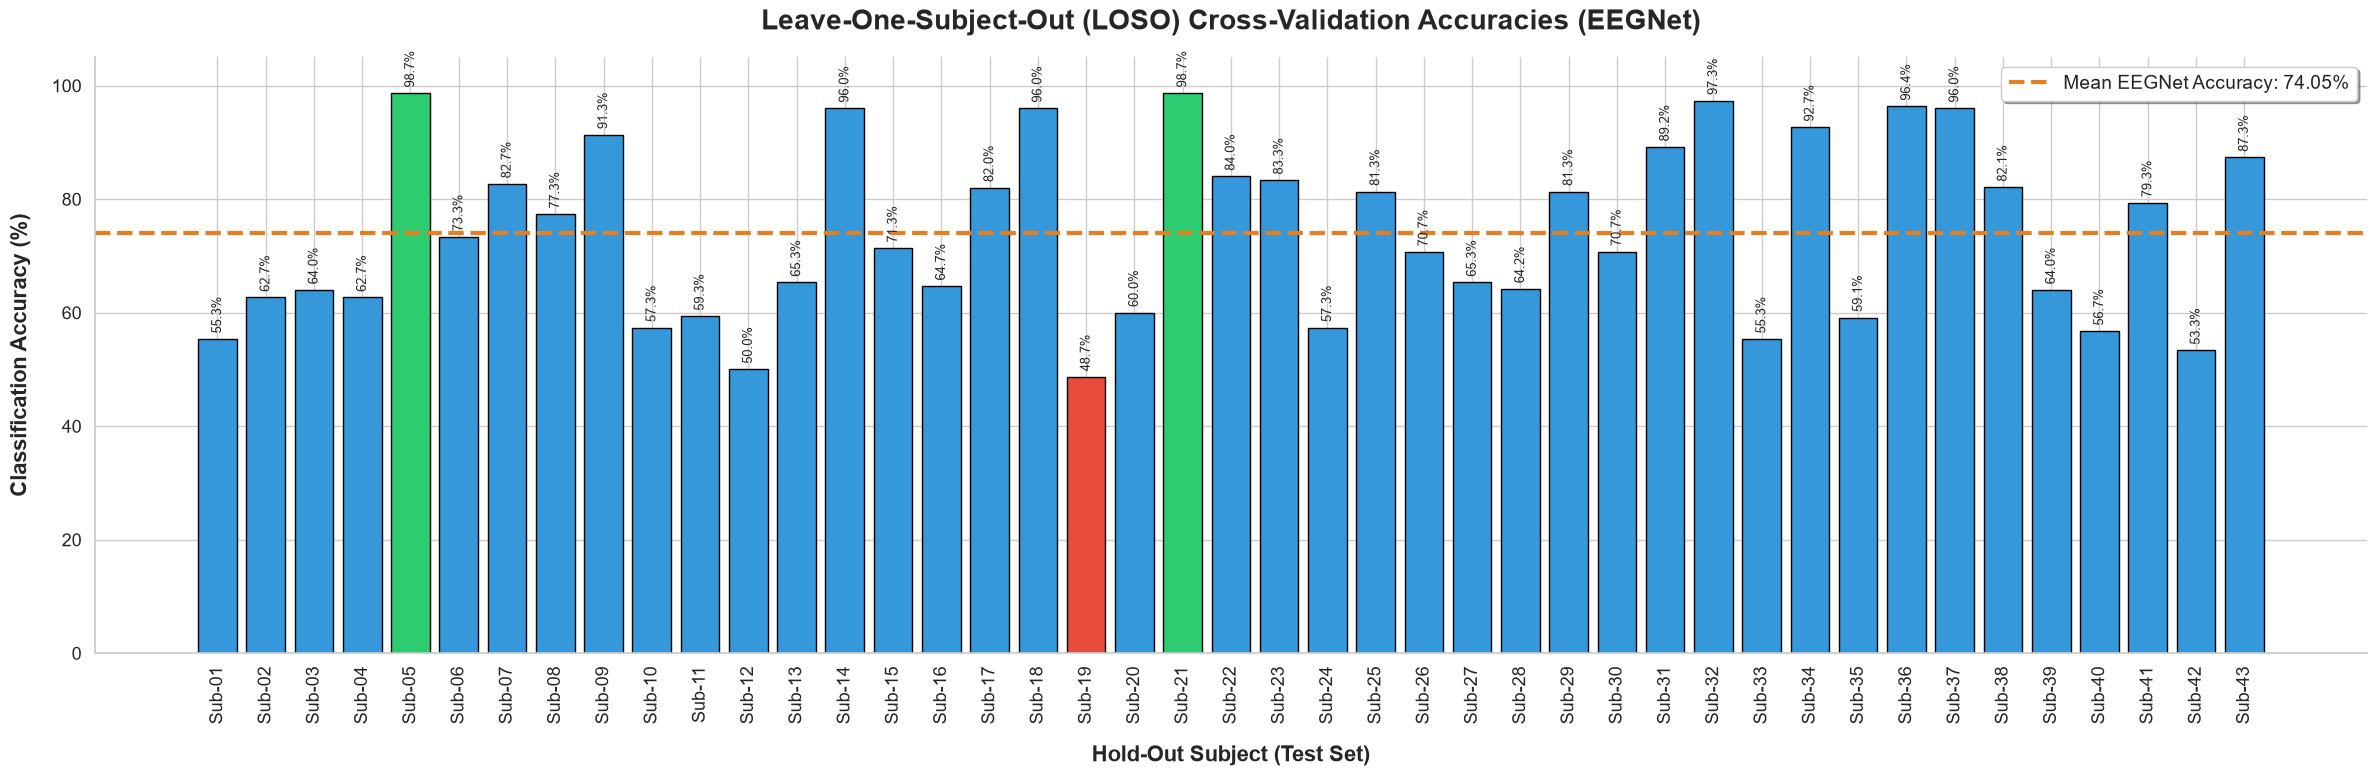

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming 'loso_accuracies' is the list generated by your EEGNet LOSO pipeline
# (e.g., loso_accuracies = [0.74, 0.82, 0.65, ...])
accuracies = np.array(loso_accuracies) * 100 # Convert decimal to percentage

# Generate Subject IDs (e.g., Sub-01, Sub-02 ... Sub-71) based on the length of the list
subject_ids = [f'Sub-{i+1:02d}' for i in range(len(accuracies))]

# Calculate statistics
mean_acc = np.mean(accuracies)
max_acc = np.max(accuracies)
min_acc = np.min(accuracies)

plt.figure(figsize=(24, 8))
sns.set(style="whitegrid", font_scale=1.2)

# Create a color palette: standard blue, but highlight the best and worst in different colors
colors = ['#2ecc71' if acc == max_acc else '#e74c3c' if acc == min_acc else '#3498db' for acc in accuracies]

# Create the bar plot
bars = plt.bar(subject_ids, accuracies, color=colors, edgecolor='black', linewidth=1)

# Add a horizontal line for the Mean Accuracy
plt.axhline(y=mean_acc, color='#e67e22', linestyle='--', linewidth=3, label=f'Mean EEGNet Accuracy: {mean_acc:.2f}%')

# Add the exact percentage text on top of every single bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=9, rotation=90)

# Formatting the plot
plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Accuracies (EEGNet)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hold-Out Subject (Test Set)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylim(0, 105) # Set Y-axis slightly above 100 to fit the text labels
plt.xticks(rotation=90) # Rotate subject IDs so they don't overlap

# Add a legend
plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True)

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()